# MAUDE abstention sweep -- regular vs abstention model

One scraped MAUDE dataset (4-class severity from redacted narratives: Malfunction /
Basic injury / Serious injury / Death). Every hyperparameter config (class_weight /
capacity / dropout / lr) is trained with the learned-abstention term `-log(o*p_y + r)`
over the **full** payoff sweep **o** (1.0 .. 5.0), replicated across seeds.

The notebook then **auto-picks the best config** -- ranked by forced macro-F1 in the
plain-classifier regime (largest `o`) -- freezes it, and draws every figure from that
one config's o-sweep. So the whole analysis is **one model**, `o` the only thing that
moves; it never changes models midway. (Set `PICK_CONFIG` in the select cell to
override the auto-pick.)

The **regular baseline** is that same model at the largest `o`: there the reject
threshold `1/o` drops below chance (0.25 for 4 classes), so it never abstains -- a
plain classifier. Lowering `o` turns abstention on: the model declines the rows it is
unsure about and is more accurate on the rows it keeps.

Paper-ready figures write to `figs/fig_maude_*.{png,pdf}`:

| figure | what it shows |
|---|---|
| `fig_maude_selective_vs_o` | selective accuracy (kept rows) vs `o` |
| `fig_maude_noabstain_vs_abstain` | accuracy vs coverage: no-abstention baseline vs abstention model |
| `fig_maude_noabstain_vs_abstain_bar` | non-abstention vs abstention accuracy (bar chart, synthetic-notebook format) |
| `fig_maude_confusion_baseline` | per-class confusion for the baseline -- where the accuracy really comes from |

Prereq: run the sweep first. Generated into the repo root next to
`synthetic_analysis.ipynb`; it finds the sweep data automatically.


## Load the sweep

In [1]:
from __future__ import annotations

import json
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

# find the repo root: walk up from the cwd; if that fails (e.g. the notebook was moved
# to the home dir), fall back to the absolute repo path baked in at generation time.
root = Path.cwd()
while not (root / "real-data" / "cluster" / "manifest.json").exists() and root != root.parent:
    root = root.parent
if not (root / "real-data" / "cluster" / "manifest.json").exists():
    root = Path(r"/Users/raham/Desktop/work/paper")
manifest = json.loads((root / "real-data" / "cluster" / "manifest.json").read_text())
print("runs in matrix:", len(manifest["runs"]))
print("base config    :", manifest["base"])
print("seeds          :", manifest["seeds"])


def _load_one(r):
    """Read one run's metrics JSON into a flat row (or mark it missing)."""
    p = root / r["metrics"]
    try:
        m = json.loads(p.read_text())
    except FileNotFoundError:
        return ("missing", r["run_id"])
    lr_ = m.get("learned_reject") or {}        # None if a run had no abstain column
    cb = m.get("confidence_baseline") or {}    # legacy field; unused in the main story
    f = m["forced"]
    return ("ok", {
        "run_id": r["run_id"], "loss": r.get("loss"), "o": r["o"],
        "class_weight": r.get("class_weight"), "seed": r["seed"],
        "hidden": r.get("hidden"), "dropout": r.get("dropout"), "lr": r.get("lr"),
        "studies": r.get("studies", []),
        "forced_acc": f["accuracy"], "forced_f1": f.get("f1"),
        "forced_macro_f1": f.get("macro_f1"), "forced_auc": f.get("roc_auc"),
        "mean_abstain": m["mean_abstain_prob"],
        "learned_cov": lr_.get("coverage"), "learned_sel_acc": lr_.get("selective_accuracy"),
        "conf_cov": cb.get("coverage"), "conf_sel_acc": cb.get("selective_accuracy"),
        "gain_vs_conf": m.get("gain_vs_conf"),
        "_metrics_path": str(p),
    })


def load_rows():
    """One flat row per run. Reads the ~thousands of metrics JSONs CONCURRENTLY --
    reading them one-at-a-time is I/O-bound and crawls on a shared cluster filesystem."""
    rows, missing = [], []
    with ThreadPoolExecutor(max_workers=32) as ex:
        for kind, val in ex.map(_load_one, manifest["runs"]):
            (rows if kind == "ok" else missing).append(val)
    if missing:
        print(f"WARNING: {len(missing)} runs have no metrics yet (still training?):")
        print("  " + ", ".join(missing[:12]) + (" ..." if len(missing) > 12 else ""))
    return pd.DataFrame(rows)


df = load_rows()
print(f"loaded {len(df)} of {len(manifest['runs'])} runs")


def study(name):
    if not len(df) or "studies" not in df.columns:
        return df.iloc[0:0]
    return df[df["studies"].apply(lambda s: name in (s or []))]


def seed_mean(frame, keys, metrics):
    """Average over seeds -> one row per config (+ std for error bars)."""
    metrics = [m for m in metrics if m in frame.columns]
    g = frame.groupby(keys, dropna=False)[metrics]
    out = g.mean().reset_index()
    for m in metrics:
        out[m + "_std"] = g.std().reset_index()[m].values
    return out


def load_curve(metrics_path, key):
    """Return (coverage, selective_accuracy) arrays from a run's swept curve."""
    m = json.loads(Path(metrics_path).read_text())
    c = pd.DataFrame(m[key])
    c = c.dropna(subset=["coverage", "selective_accuracy"])
    return c["coverage"].to_numpy(), c["selective_accuracy"].to_numpy()

runs in matrix: 2255
base config    : {'loss': 'abstention', 'o': 2.0, 'class_weight': 'none', 'hidden': '256,128', 'dropout': 0.0, 'lr': 0.001, 'epochs': 80}
seeds          : [0, 1, 2, 3, 4]
loaded 2255 of 2255 runs


In [2]:
# Shared paper-quality plotting style + a figs/ saver.
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.size": 12, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 12, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_LEARNED, C_CONF = "#1f77b4", "#d62728"   # learned reject vs confidence baseline
# Same palette as the synthetic notebook so the two papers read as one system:
# non-abstention = blue, abstention = orange (used by the accuracy-comparison bar chart).
COLORS = {"cascade": "#2c7fb8", "abstention": "#e6550d", "bayes": "#333333"}
FIGS = root / "figs"; FIGS.mkdir(exist_ok=True)


def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"{name}.{ext}")
    print("saved", FIGS / f"{name}.png")

## Select the best config

Rank every hyperparameter config (each swept over the full `o` range) by forced macro-F1 in the plain-classifier regime, freeze the winner, and draw every figure below from that one config's o-sweep -- so nothing changes models midway. Set `PICK_CONFIG` to override.

In [3]:
# AUTO-PICK the best config. Every hyperparameter config was swept over the FULL o
# range; here we rank the configs by forced macro-F1 in the PLAIN-CLASSIFIER regime --
# the largest o, where the reject threshold 1/o is below chance (0.25 for 4 classes) so
# abstention is off and forced macro-F1 is pure classifier quality. We FREEZE the winner
# and set `PAY` = that one config's o-sweep; every figure below draws from PAY only, so
# nothing changes models midway. Set PICK_CONFIG to override the auto-pick.
PICK_CONFIG = None    # e.g. {"class_weight": "sqrt", "dropout": 0.1}; None = auto-pick
CONFIG_COLS = ["class_weight", "hidden", "dropout", "lr"]

pay_all = study("payoff")
if len(pay_all):
    o_max = pay_all["o"].max()
    ranking = (seed_mean(pay_all[pay_all["o"] == o_max], CONFIG_COLS,
                         ["forced_macro_f1", "forced_acc"])
               .sort_values("forced_macro_f1", ascending=False).reset_index(drop=True))
    print(f"config ranking by forced macro-F1 at o={o_max:g} (plain-classifier regime, "
          f"mean over seeds):")
    print(ranking.round(4).to_string(index=False))
    if PICK_CONFIG is not None:
        CHOSEN = {c: PICK_CONFIG.get(c, manifest["base"][c]) for c in CONFIG_COLS}
    else:
        CHOSEN = {c: ranking.loc[0, c] for c in CONFIG_COLS}
    mask = np.ones(len(pay_all), bool)
    for c in CONFIG_COLS:
        mask &= (pay_all[c] == CHOSEN[c])
    PAY = pay_all[mask]
    print("\nchosen config (frozen for every figure below):")
    print("  " + ", ".join(f"{c}={CHOSEN[c]}" for c in CONFIG_COLS))
    print(f"  o-sweep runs for this config: {len(PAY)}")
else:
    PAY = pay_all
    print("no payoff runs loaded yet -- run the sweep first")

config ranking by forced macro-F1 at o=5 (plain-classifier regime, mean over seeds):
class_weight     hidden  dropout     lr  forced_macro_f1  forced_acc  forced_macro_f1_std  forced_acc_std
        none    256,128      0.0 0.0010           0.8535      0.9468               0.0026          0.0007
        sqrt    256,128      0.0 0.0010           0.8270      0.9405               0.0083          0.0032
        none    256,128      0.3 0.0010           0.8083      0.9419               0.0067          0.0015
        none     128,64      0.0 0.0010           0.8055      0.9403               0.0085          0.0011
        none    256,128      0.1 0.0010           0.8009      0.9392               0.0229          0.0026
        none 256,128,64      0.0 0.0010           0.8008      0.9389               0.0137          0.0012
        none    256,128      0.2 0.0010           0.7994      0.9388               0.0208          0.0030
        none    256,128      0.0 0.0030           0.7968      0.938

## Regular baseline (no abstention)

The largest-`o` model, which never abstains -- the plain classifier the abstention models are compared against.

In [4]:
# The REGULAR BASELINE = the abstention model at the LARGEST o. There 1/o is below
# chance (0.25 for 4 classes), so the model effectively never abstains -- it is a
# plain classifier that predicts on EVERY row. Everything below is the SAME model at
# smaller o (abstention turned on). On the skewed 4 classes, MACRO-F1 / balanced
# accuracy matter more than plain accuracy, which Malfunction (~65% of rows) can carry
# on its own.
pay = PAY
if len(pay):
    o_max = pay["o"].max()
    b = seed_mean(pay[pay["o"] == o_max], ["o"],
                  ["forced_acc", "forced_macro_f1", "mean_abstain"]).iloc[0]
    print(f"regular baseline = abstention model at o={o_max:g}  (never abstains)")
    print(f"  forced accuracy   : {b.forced_acc:.4f}   (predicts on all rows)")
    print(f"  forced macro-F1   : {b.forced_macro_f1:.4f}")
    print(f"  mean abstain prob : {b.mean_abstain:.4f}   (~0 confirms it does not abstain)")
    display(seed_mean(pay, ["o"], ["forced_acc", "forced_macro_f1", "mean_abstain"])
            .sort_values("o").round(4))
else:
    print("no payoff runs loaded yet -- run the sweep first")

regular baseline = abstention model at o=5  (never abstains)
  forced accuracy   : 0.9468   (predicts on all rows)
  forced macro-F1   : 0.8535
  mean abstain prob : 0.0001   (~0 confirms it does not abstain)


,o,forced_acc,forced_macro_f1,mean_abstain,forced_acc_std,forced_macro_f1_std,mean_abstain_std
0,1.0,0.6968,0.2053,0.9999,0.0000,0.0000,0.0000
1,1.1,0.6968,0.2053,0.9999,0.0000,0.0000,0.0000
2,1.2,0.7000,0.2157,0.4104,0.0034,0.0110,0.0055
3,1.3,0.6992,0.2128,0.3894,0.0021,0.0064,0.0039
4,1.4,0.6979,0.2088,0.3702,0.0015,0.0048,0.0021
5,1.5,0.6990,0.2118,0.3639,0.0030,0.0091,0.0031
6,1.6,0.7008,0.2175,0.3570,0.0037,0.0112,0.0050
7,1.7,0.7118,0.2409,0.3529,0.0218,0.0464,0.0051
8,1.8,0.7049,0.2281,0.3446,0.0070,0.0182,0.0048
9,1.9,0.7076,0.2336,0.3454,0.0141,0.0347,0.0040


## Risk / accuracy vs coverage and vs o

The two headline diagrams: **selective accuracy vs `o`** (kept rows) and **accuracy (risk) vs coverage** (no-abstention baseline vs the abstention model). `MIN_COV` drops degenerate low-coverage points. **Saved: `fig_maude_selective_vs_o`, `fig_maude_noabstain_vs_abstain`.**

chosen config: {'class_weight': 'none', 'hidden': '256,128', 'dropout': np.float64(0.0), 'lr': np.float64(0.001)}
saved /fs1/projects/ProtoOKN/medical-device-rca/figs/fig_maude_selective_vs_o.png


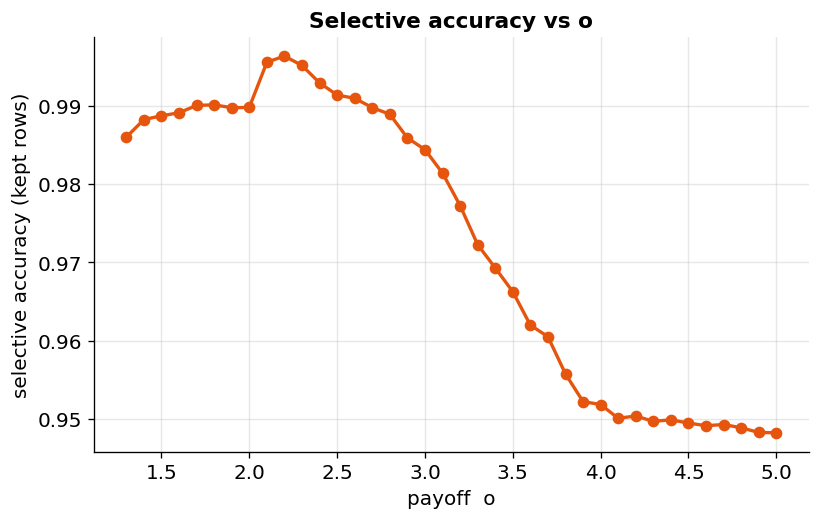

saved /fs1/projects/ProtoOKN/medical-device-rca/figs/fig_maude_noabstain_vs_abstain.png


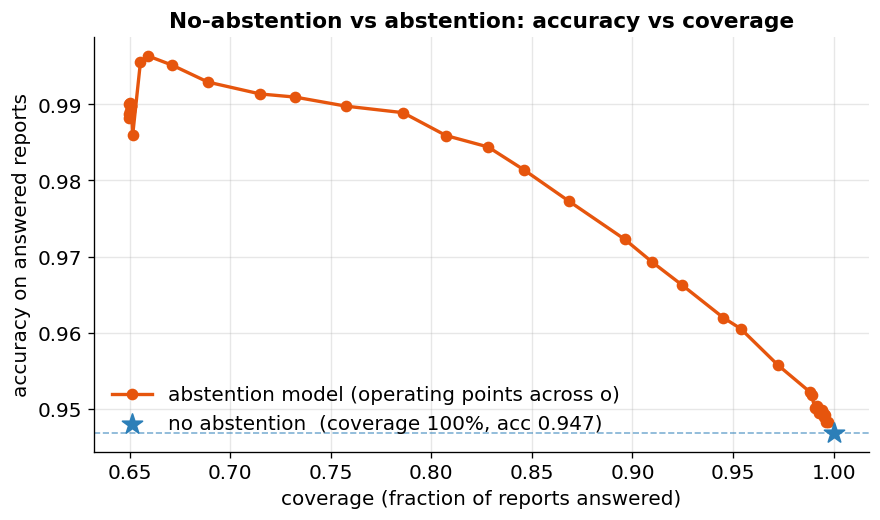

  o  forced_acc  sel_acc  coverage
1.0      0.6968      NaN    0.0000
1.1      0.6968      NaN    0.0000
1.2      0.7000   0.9991    0.4400
1.3      0.6992   0.9860    0.6515
1.4      0.6979   0.9882    0.6497
1.5      0.6990   0.9887    0.6499
1.6      0.7008   0.9891    0.6504
1.7      0.7118   0.9901    0.6499
1.8      0.7049   0.9901    0.6501
1.9      0.7076   0.9898    0.6509
2.0      0.7144   0.9898    0.6509
2.1      0.8109   0.9956    0.6554
2.2      0.8357   0.9964    0.6593
2.3      0.8364   0.9952    0.6712
2.4      0.8583   0.9929    0.6890
2.5      0.8795   0.9914    0.7149
2.6      0.9014   0.9910    0.7323
2.7      0.9220   0.9898    0.7576
2.8      0.9429   0.9889    0.7859
2.9      0.9434   0.9859    0.8074
3.0      0.9433   0.9844    0.8282
3.1      0.9436   0.9814    0.8460
3.2      0.9440   0.9773    0.8685
3.3      0.9442   0.9723    0.8962
3.4      0.9469   0.9693    0.9097
3.5      0.9460   0.9662    0.9247
3.6      0.9464   0.9620    0.9451
3.7      0.9467   0.

In [5]:
# The two headline diagrams: accuracy vs o, and accuracy (risk) vs coverage. Re-derives
# the chosen config (same rule as the Select cell). Uses `root`/`manifest` from the Load
# cell. MIN_COV drops degenerate low-coverage points where the model abstains on ~all rows.
MIN_COV = 0.60          # drop o where the model answers too few rows to be meaningful

accdf_rows = []
for r in manifest["runs"]:
    p = root / r["metrics"]
    if not p.exists():
        continue
    m = json.loads(p.read_text())
    lr = m.get("learned_reject") or {}
    accdf_rows.append({"o": r["o"], "class_weight": r["class_weight"], "hidden": r["hidden"],
                       "dropout": r["dropout"], "lr": r["lr"], "seed": r["seed"],
                       "forced_acc": m["forced"]["accuracy"],
                       "sel_acc": lr.get("selective_accuracy"),
                       "coverage": lr.get("coverage"),
                       "macro_f1": m["forced"].get("macro_f1")})
accdf = pd.DataFrame(accdf_rows)

# auto-pick the best config (highest forced macro-F1 at the largest o), then average over seeds
COLS = ["class_weight", "hidden", "dropout", "lr"]; om = accdf["o"].max()
chosen = accdf[accdf["o"] == om].groupby(COLS)["macro_f1"].mean().idxmax()
mask = np.ones(len(accdf), bool)
for k, v in zip(COLS, chosen):
    mask &= (accdf[k] == v)
d = accdf[mask].groupby("o").mean(numeric_only=True).reset_index().sort_values("o")
print("chosen config:", dict(zip(COLS, chosen)))

# --- Diagram 1: o vs selective accuracy (only where coverage is meaningful) ---
d2 = d.dropna(subset=["sel_acc"])
d2 = d2[d2["coverage"] >= MIN_COV]
fig2, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(d2["o"], d2["sel_acc"], marker="o", color=COLORS["abstention"], lw=2)
ax.set_xlabel("payoff  o"); ax.set_ylabel("selective accuracy (kept rows)")
ax.set_title("Selective accuracy vs o")
ax.grid(alpha=0.3); fig2.tight_layout(); save(fig2, "fig_maude_selective_vs_o"); plt.show()

# --- Diagram 2: no-abstention vs abstention, accuracy vs coverage ---
base_acc = float(d.loc[d["o"] == om, "forced_acc"].iloc[0])       # baseline: full coverage
frontier = d.dropna(subset=["sel_acc"])
frontier = frontier[frontier["coverage"] >= MIN_COV].sort_values("coverage")
fig3, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(frontier["coverage"], frontier["sel_acc"], marker="o", color=COLORS["abstention"], lw=2,
        label="abstention model (operating points across o)")
ax.scatter([1.0], [base_acc], color=COLORS["cascade"], s=160, marker="*", zorder=5,
           label=f"no abstention  (coverage 100%, acc {base_acc:.3f})")
ax.axhline(base_acc, color=COLORS["cascade"], ls="--", lw=1, alpha=0.6)
ax.set_xlabel("coverage (fraction of reports answered)")
ax.set_ylabel("accuracy on answered reports")
ax.set_title("No-abstention vs abstention: accuracy vs coverage")
ax.legend(); ax.grid(alpha=0.3); fig3.tight_layout(); save(fig3, "fig_maude_noabstain_vs_abstain"); plt.show()

print(d[["o", "forced_acc", "sel_acc", "coverage"]].round(4).to_string(index=False))

## Accuracy comparison (non-abstention vs abstention)

The non-abstention baseline at full coverage vs abstention's selective accuracy on the reports it answers, as a bar chart -- same format and colors as the synthetic notebook. Coverage annotated on the abstention bar. **Saved: `fig_maude_noabstain_vs_abstain_bar`.**

saved /fs1/projects/ProtoOKN/medical-device-rca/figs/fig_maude_noabstain_vs_abstain_bar.png


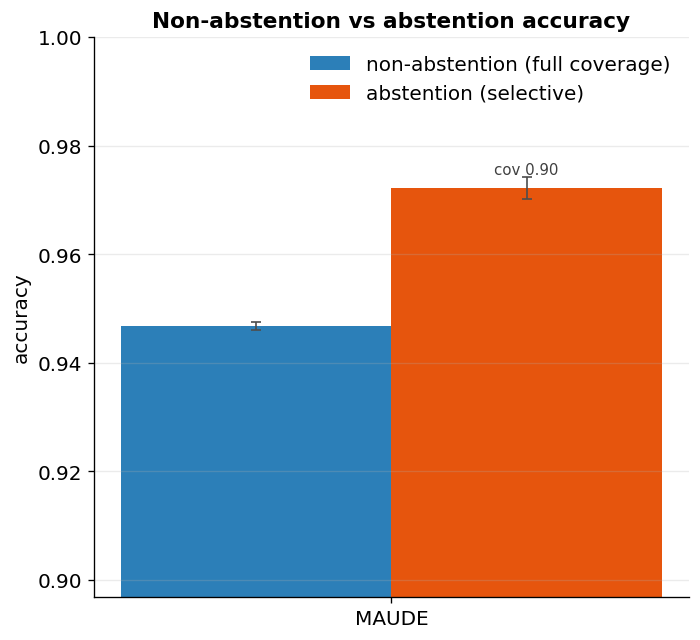

non-abstention 0.9468   abstention 0.9723 @ cov 0.90   gain +0.0254   (chosen o=3.3)


In [6]:
# ACCURACY COMPARISON: non-abstention (full coverage) vs abstention -- the MAUDE analog of
# the synthetic notebook's bar chart, in the SAME format and colors. Non-abstention (blue) =
# the plain classifier at the largest o, which predicts on EVERY report. Abstention (orange) =
# the same family at the mid o that best trades coverage for accuracy on the reports it keeps:
#   net = (selective_acc - non_abstention_acc) - PENALTY*(1 - coverage),  coverage >= COV_MIN.
# So the abstention bar sits on the same operating point as the risk-coverage frontier above.
# Coverage is annotated on the abstention bar; error bars = +/-1 std over seeds.
PENALTY = 0.20
COV_MIN = 0.60
pay = PAY
if len(pay):
    agg = (seed_mean(pay, ["o"], ["forced_acc", "learned_sel_acc", "learned_cov"])
           .sort_values("o").reset_index(drop=True))
    i_base = int(agg["o"].idxmax()); o_base = float(agg.loc[i_base, "o"])
    na_m = float(agg.loc[i_base, "forced_acc"]); na_s = float(agg.loc[i_base, "forced_acc_std"])
    cand = (agg[agg["o"] < o_base].dropna(subset=["learned_sel_acc", "learned_cov"])
            .reset_index(drop=True))
    covv = cand["learned_cov"].to_numpy(); accv = cand["learned_sel_acc"].to_numpy()
    net = (accv - na_m) - PENALTY * (1 - covv)
    net = np.where(covv >= COV_MIN, net, -np.inf)
    if len(cand) and np.isfinite(net).any():
        j = int(np.argmax(net))
        o_star = float(cand.loc[j, "o"]); ab_m = float(accv[j]); ab_c = float(covv[j])
        ab_s = float(cand.loc[j, "learned_sel_acc_std"])

        x = np.arange(1); w = 0.38
        fig, ax = plt.subplots(figsize=(6.0, 5.5))
        ekw = dict(ecolor="0.3", capsize=3, elinewidth=1)
        ax.bar(x - w/2, [na_m], w, yerr=[na_s], color=COLORS["cascade"],
               label="non-abstention (full coverage)", error_kw=ekw)
        ax.bar(x + w/2, [ab_m], w, yerr=[ab_s], color=COLORS["abstention"],
               label="abstention (selective)", error_kw=ekw)
        ax.annotate(f"cov {ab_c:.2f}", (float(x[0] + w/2), ab_m + (0 if np.isnan(ab_s) else ab_s)),
                    ha="center", va="bottom", fontsize=9, color="0.25")   # coverage on the abstention bar
        ax.set_ylim(max(0.0, min(na_m, ab_m) - 0.05), 1.0)
        ax.set_xticks(x); ax.set_xticklabels(["MAUDE"])
        ax.set_ylabel("accuracy")
        ax.set_title("Non-abstention vs abstention accuracy")
        ax.legend(loc="upper right"); ax.grid(axis="x", alpha=0)
        fig.tight_layout(); save(fig, "fig_maude_noabstain_vs_abstain_bar"); plt.show()
        print(f"non-abstention {na_m:.4f}   abstention {ab_m:.4f} @ cov {ab_c:.2f}   "
              f"gain {ab_m - na_m:+.4f}   (chosen o={o_star:g})")
    else:
        print(f"no abstaining o with coverage >= {COV_MIN} for the chosen config")
else:
    print("no payoff-study runs loaded")

## Per-class breakdown

Where the accuracy actually comes from: per-class precision/recall/F1 and the confusion matrix for the baseline. Accuracy hides the rare classes; this exposes them. **Saved: `fig_maude_confusion_baseline`.**

plain-classifier baseline (o=5), summed over 5 seeds:
         class  support  precision  recall    F1  F1_std
   Malfunction   185475      0.971   0.980 0.975   0.001
  Basic injury    44995      0.885   0.869 0.877   0.002
Serious injury    33900      0.901   0.891 0.896   0.001
         Death     1800      0.803   0.569 0.666   0.011

macro-F1 = 0.854   accuracy = 0.947
saved /fs1/projects/ProtoOKN/medical-device-rca/figs/fig_maude_confusion_baseline.png


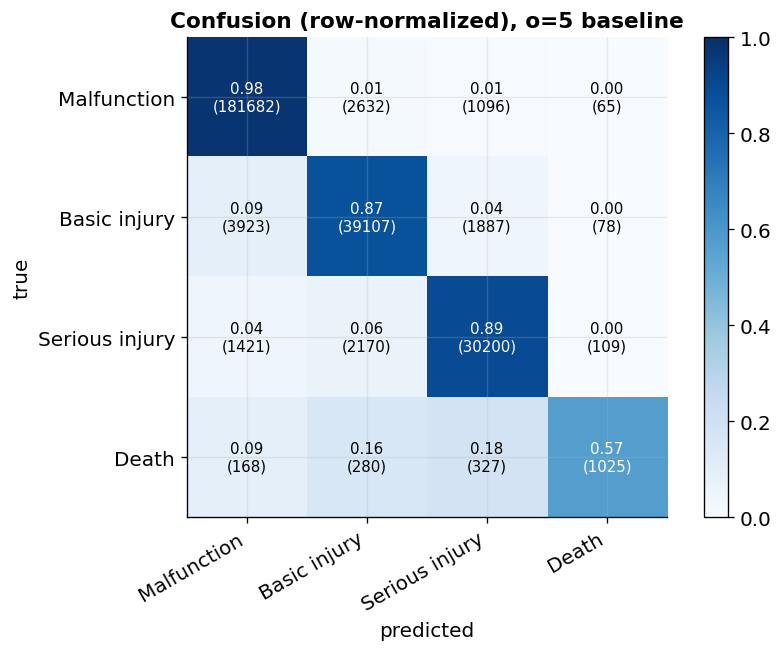

In [7]:
# PER-CLASS breakdown of the chosen config's plain-classifier baseline (largest o).
# Accuracy is carried by the majority classes; this shows WHERE the model actually works.
# Reads per_class_f1 + confusion_matrix already in each run's JSON (F1 averaged over
# seeds, confusion counts summed). macro-F1 = mean of the per-class F1 -- the honest
# number on the skewed classes. Watch the recall column and the off-diagonal: rare
# classes (e.g. Death) crater and leak into the majority columns.
LABELS = {4: ["Malfunction", "Basic injury", "Serious injury", "Death"],
          3: ["Malfunction", "Injury", "Death"], 2: ["neg", "pos"]}
base = PAY[PAY["o"] == PAY["o"].max()]
mats, f1s, ncls = [], [], None
for p in base["_metrics_path"]:
    m = json.loads(Path(p).read_text()); ncls = m["n_classes"]
    mats.append(np.array(m["forced"]["confusion_matrix"], dtype=float))
    f1s.append(np.array(m["forced"]["per_class_f1"], dtype=float))
if mats:
    names = LABELS.get(ncls, [f"class {i}" for i in range(ncls)])
    C = np.sum(mats, axis=0); support = C.sum(1)
    recall = np.divide(np.diag(C), support, out=np.zeros(ncls), where=support > 0)
    precision = np.divide(np.diag(C), C.sum(0), out=np.zeros(ncls), where=C.sum(0) > 0)
    f1_mean, f1_std = np.mean(f1s, axis=0), np.std(f1s, axis=0)
    tbl = pd.DataFrame({"class": names, "support": support.astype(int),
                        "precision": precision.round(3), "recall": recall.round(3),
                        "F1": f1_mean.round(3), "F1_std": f1_std.round(3)})
    print(f"plain-classifier baseline (o={PAY['o'].max():g}), summed over {len(mats)} seeds:")
    print(tbl.to_string(index=False))
    print(f"\nmacro-F1 = {f1_mean.mean():.3f}   accuracy = {np.diag(C).sum() / C.sum():.3f}")
    Cn = C / support[:, None].clip(min=1)
    fig, ax = plt.subplots(figsize=(1.6 * ncls + 1, 1.4 * ncls))
    im = ax.imshow(Cn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(ncls)); ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_yticks(range(ncls)); ax.set_yticklabels(names)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"Confusion (row-normalized), o={PAY['o'].max():g} baseline")
    for i in range(ncls):
        for j in range(ncls):
            ax.text(j, i, f"{Cn[i, j]:.2f}\n({int(C[i, j])})", ha="center", va="center",
                    color="white" if Cn[i, j] > 0.5 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046); fig.tight_layout()
    save(fig, "fig_maude_confusion_baseline"); plt.show()
else:
    print("no baseline runs loaded")

## Optimal operating point

In [8]:
# Best operating point for the CHOSEN config: the o with the highest learned selective
# accuracy at its target coverage, next to that config's regular baseline (largest o).
pay = PAY
if len(pay):
    keep = pay.dropna(subset=["learned_sel_acc"])
    if len(keep):
        agg = seed_mean(keep, ["o"], ["learned_sel_acc", "learned_cov"])
        best = agg.loc[agg["learned_sel_acc"].idxmax()]
        print(f"best payoff o={best.o:g}: learned selective accuracy={best.learned_sel_acc:.4f} "
              f"@ coverage={best.learned_cov:.3f}")
    o_base = pay["o"].max()
    b = float(pay[pay["o"] == o_base]["forced_acc"].mean())
    print(f"regular baseline (o={o_base:g}) forced accuracy: {b:.4f}  (predicts on all rows)")
else:
    print("no runs loaded")

best payoff o=1.2: learned selective accuracy=0.9991 @ coverage=0.440
regular baseline (o=5) forced accuracy: 0.9468  (predicts on all rows)
